Encoding and scaling

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("prachi13/customer-analytics")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'customer-analytics' dataset.
Path to dataset files: /kaggle/input/customer-analytics


In [ ]:
import pandas as pd
df=pd.read_csv("/kaggle/input/customer-analytics/Train.csv")

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline



# Separate features and target (assuming target is Reached.on.Time_Y.N)
X = df.drop(columns=['Reached.on.Time_Y.N'])
y = df['Reached.on.Time_Y.N']

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(exclude=['object']).columns.tolist()

In [ ]:
# 1. Label Encoding
X_label_encoded = X.copy()
for col in categorical_cols:
    le = LabelEncoder()
    X_label_encoded[col] = le.fit_transform(X_label_encoded[col])

# 2. One-Hot Encoding
onehot_encoder = ColumnTransformer([
    ('onehot', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
], remainder='passthrough')

# 3. Ordinal Encoding
ordinal_encoder = ColumnTransformer([
    ('ordinal', OrdinalEncoder(), categorical_cols)
], remainder='passthrough')


In [ ]:
# Standardization
std_pipeline = Pipeline(steps=[
    ('encoder', onehot_encoder),
    ('scaler', StandardScaler())
])

# Normalization
norm_pipeline = Pipeline(steps=[
    ('encoder', onehot_encoder),
    ('scaler', MinMaxScaler())
])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply Standardization
X_train_std = std_pipeline.fit_transform(X_train)
X_train_std_df = pd.DataFrame(X_train_std)

# Apply Normalization
X_train_norm = norm_pipeline.fit_transform(X_train)
X_train_norm_df = pd.DataFrame(X_train_norm)

In [ ]:
print("Before Encoding & Scaling:\n", X_train.head(4))

Before Encoding & Scaling:
           ID Warehouse_block Mode_of_Shipment  Customer_care_calls  \
8965    8966               F             Ship                    3   
5936    5937               A             Ship                    6   
10656  10657               D             Ship                    2   
3328    3329               C             Ship                    5   

       Customer_rating  Cost_of_the_Product  Prior_purchases  \
8965                 5                  178                3   
5936                 3                  202                4   
10656                5                  277                3   
3328                 5                  219                2   

      Product_importance Gender  Discount_offered  Weight_in_gms  
8965                 low      F                 7           4135  
5936              medium      F                 3           4496  
10656             medium      M                 6           1032  
3328              medium      M 

In [ ]:
print("\nAfter One-Hot + Standardization:\n", X_train_std_df.head(4))


After One-Hot + Standardization:
          0         1         2         3         4         5         6   \
0 -0.444924 -0.447854 -0.450959  1.417838 -0.433509  0.686231  1.034579   
1 -0.444924 -0.447854 -0.450959 -0.705299 -0.433509  0.686231 -0.966577   
2 -0.444924 -0.447854  2.217495 -0.705299 -0.433509  0.686231 -0.966577   
3 -0.444924  2.232871 -0.450959 -0.705299 -0.433509  0.686231 -0.966577   

         7         8         9         10        11        12        13  \
0 -0.870858 -1.001706  1.090321 -0.925605  1.422087 -0.670120 -0.378680   
1  1.148293 -1.001706  0.135777  1.697108  0.003949 -0.173246  0.273631   
2  1.148293  0.998297  1.623214 -1.799843  1.422087  1.379486 -0.378680   
3  1.148293  0.998297 -0.686095  0.822870  1.422087  0.178707 -1.030992   

         14        15  
0 -0.392911  0.311901  
1 -0.638968  0.532606  
2 -0.454426 -1.585178  
3 -0.577454  0.406052  


In [ ]:
print("\nAfter One-Hot + Normalization:\n", X_train_norm_df.head(3))


After One-Hot + Normalization:
     0    1    2    3    4    5    6    7    8         9    10   11        12  \
0  0.0  0.0  0.0  1.0  0.0  1.0  1.0  0.0  0.0  0.815131  0.2  1.0  0.383178   
1  0.0  0.0  0.0  0.0  0.0  1.0  0.0  1.0  0.0  0.539693  0.8  0.5  0.495327   
2  0.0  0.0  1.0  0.0  0.0  1.0  0.0  1.0  1.0  0.968901  0.0  1.0  0.845794   

      13        14        15  
0  0.125  0.093750  0.457852  
1  0.250  0.031250  0.510592  
2  0.125  0.078125  0.004529  


Feature Selection

In [ ]:
from sklearn.feature_selection import VarianceThreshold
X_mean_encoded = X.copy()

# Use only numeric columns for variance threshold
X_num = X_mean_encoded.select_dtypes(include=['int64','float64'])

# Variance Threshold
selector = VarianceThreshold(threshold=0.01)  # remove low-variance features
X_var = selector.fit_transform(X_num)

print("=== Filter Method: Variance Threshold ===")
print("Original shape:", X_num.shape)
print("After selection:", X_var.shape)
print("Selected features:", X_num.columns[selector.get_support(indices=True)].tolist())

=== Filter Method: Variance Threshold ===
Original shape: (10999, 7)
After selection: (10999, 7)
Selected features: ['ID', 'Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases', 'Discount_offered', 'Weight_in_gms']


Hypothesis Testing

In [ ]:
from scipy.stats import ttest_ind, chi2_contingency, f_oneway, f
from statsmodels.stats.weightstats import ztest  # Correct import for Z-test

# Use the dataset after mean encoding
X = X_mean_encoded.copy()  # numeric + encoded categorical
y = df['Reached.on.Time_Y.N']

# Significance level
alpha = 0.05

In [ ]:
# 1. Z-Test
if 'Cost_of_the_Product' in X.columns:
    z_stat, p_value = ztest(X['Cost_of_the_Product'], value=500)
    print("=== Z-Test ===")
    print("Z-Statistic:", z_stat)
    print("P-Value:", p_value)
    if p_value < alpha:
        print("Reject H0: Mean Cost_of_the_Product differs from 500\n")
    else:
        print("Fail to Reject H0: Mean Cost_of_the_Product is 500\n")

=== Z-Test ===
Z-Statistic: -632.3629152518831
P-Value: 0.0
Reject H0: Mean Cost_of_the_Product differs from 500



In [ ]:
# 2. T-Test
if 'Customer_rating' in X.columns:
    group1 = X[y==1]['Customer_rating']
    group2 = X[y==0]['Customer_rating']

    t_stat, p_value = ttest_ind(group1, group2)
    print("=== T-Test ===")
    print("T-Statistic:", t_stat)
    print("P-Value:", p_value)
    if p_value < alpha:
        print("Reject H0: Customer_rating differs between on-time vs late deliveries\n")
    else:
        print("Fail to Reject H0: Customer_rating is similar between groups\n")

=== T-Test ===
T-Statistic: 1.3758215815941237
P-Value: 0.16890489722530824
Fail to Reject H0: Customer_rating is similar between groups



In [ ]:
#F-Test
if 'Cost_of_the_Product' in X.columns:
    var1 = X[y==1]['Cost_of_the_Product'].var()
    var2 = X[y==0]['Cost_of_the_Product'].var()

    f_stat = var1 / var2
    df1 = len(X[y==1]['Cost_of_the_Product']) - 1
    df2 = len(X[y==0]['Cost_of_the_Product']) - 1
    p_value = 1 - f.cdf(f_stat, df1, df2)

    print("=== F-Test ===")
    print("F-Statistic:", f_stat)
    print("P-Value:", p_value)
    if p_value < alpha:
        print("Reject H0: Variances of Cost_of_the_Product are different\n")
    else:
        print("Fail to Reject H0: Variances are similar\n")

=== F-Test ===
F-Statistic: 1.0124952668184333
P-Value: 0.32645117502059495
Fail to Reject H0: Variances are similar



ploting probability distributions for Bernoulli, Binomial, Poisson, and Normal distributions

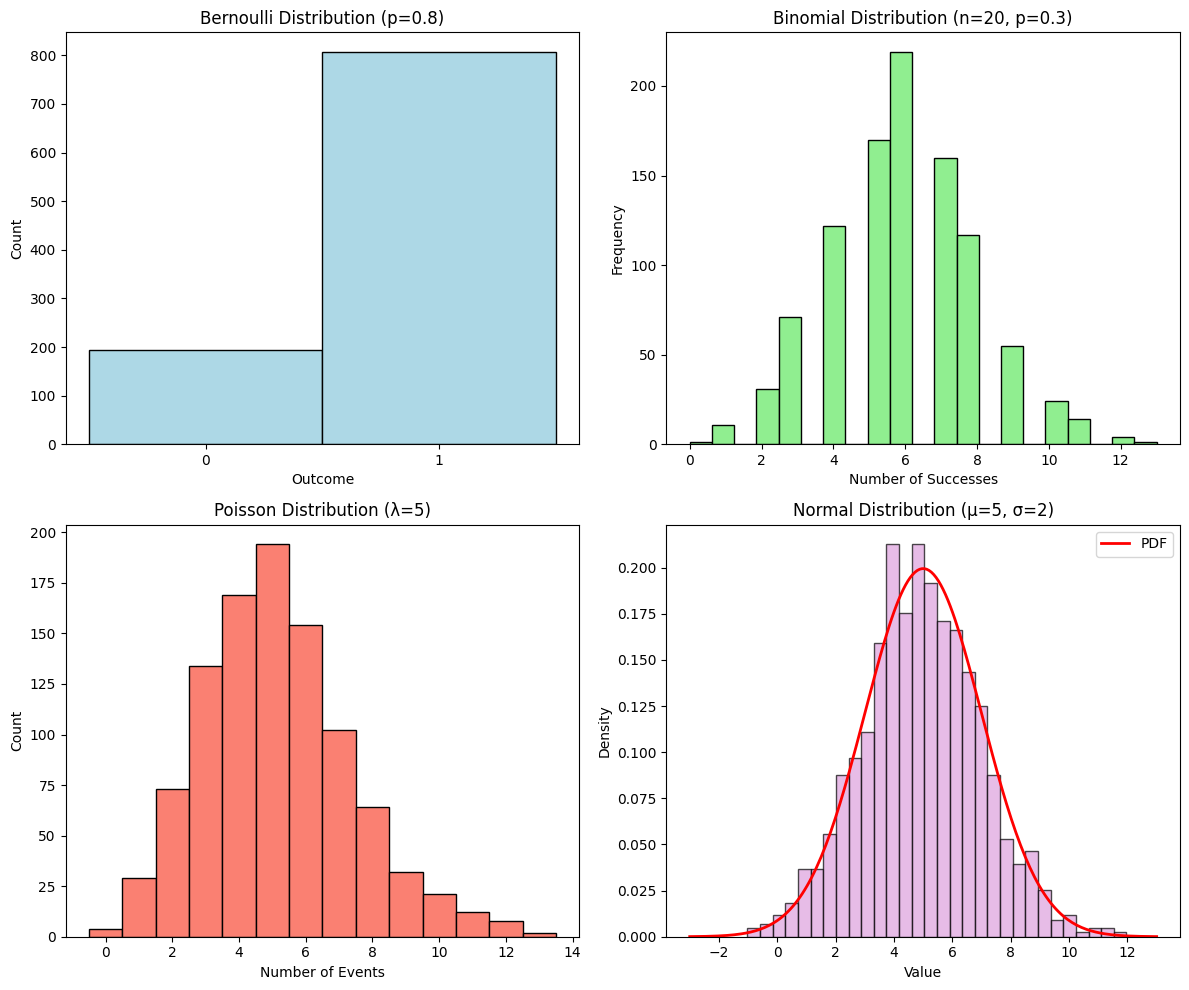

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import bernoulli, binom, poisson, norm

# ====================================
# Parameters and Sample Sizes
# ====================================
sample_size = 1000

# Bernoulli: biased coin
p_bern = 0.8
bernoulli_samples = bernoulli.rvs(p_bern, size=sample_size)

# Binomial: 20 trials with p=0.3
n_binom = 20
p_binom = 0.3
binomial_samples = binom.rvs(n=n_binom, p=p_binom, size=sample_size)

# Poisson: λ = 5
lambda_poisson = 5
poisson_samples = poisson.rvs(mu=lambda_poisson, size=sample_size)

# Normal: μ = 5, σ = 2
mu = 5
sigma = 2
normal_samples = norm.rvs(loc=mu, scale=sigma, size=sample_size)

# ====================================
# Plotting
# ====================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# --- Bernoulli ---
axes[0, 0].hist(bernoulli_samples, bins=[-0.5, 0.5, 1.5], edgecolor='black', color='lightblue')
axes[0, 0].set_title(f'Bernoulli Distribution (p={p_bern})')
axes[0, 0].set_xlabel('Outcome')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_xticks([0, 1])

# --- Binomial ---
axes[0, 1].hist(binomial_samples, bins=n_binom + 1, edgecolor='black', color='lightgreen')
axes[0, 1].set_title(f'Binomial Distribution (n={n_binom}, p={p_binom})')
axes[0, 1].set_xlabel('Number of Successes')
axes[0, 1].set_ylabel('Frequency')

# --- Poisson ---
axes[1, 0].hist(poisson_samples, bins=np.arange(poisson_samples.min(), poisson_samples.max()+1)-0.5,
                edgecolor='black', color='salmon')
axes[1, 0].set_title(f'Poisson Distribution (λ={lambda_poisson})')
axes[1, 0].set_xlabel('Number of Events')
axes[1, 0].set_ylabel('Count')

# --- Normal ---
axes[1, 1].hist(normal_samples, bins=30, density=True, edgecolor='black', color='plum', alpha=0.7)

# Overlay true PDF
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 200)
axes[1, 1].plot(x, norm.pdf(x, mu, sigma), 'r-', lw=2, label='PDF')
axes[1, 1].set_title(f'Normal Distribution (μ={mu}, σ={sigma})')
axes[1, 1].set_xlabel('Value')
axes[1, 1].set_ylabel('Density')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

Logistic Regression

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
# Features and target
X = df.drop(columns=["ID", "Reached.on.Time_Y.N"])
y = df["Reached.on.Time_Y.N"]

# Categorical and numerical columns
cat_cols = ["Warehouse_block", "Mode_of_Shipment", "Product_importance", "Gender"]
num_cols = [col for col in X.columns if col not in cat_cols]

In [ ]:
## Preprocessing: encode categoricals and scale numericals
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(drop="first"), cat_cols),
    ("num", StandardScaler(), num_cols)
])

# Full pipeline with logistic regression
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Fit the pipeline
pipeline.fit(X_train, y_train)

# Predictions
y_pred = pipeline.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.6377272727272727
Classification Report:
               precision    recall  f1-score   support

           0       0.55      0.59      0.57       887
           1       0.71      0.67      0.69      1313

    accuracy                           0.64      2200
   macro avg       0.63      0.63      0.63      2200
weighted avg       0.64      0.64      0.64      2200



Linear Regression

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# Features & Target
X = df.drop(columns=["ID", "Reached.on.Time_Y.N"])
y = df["Reached.on.Time_Y.N"]

# Categorical columns
categorical_cols = ["Warehouse_block", "Mode_of_Shipment", "Product_importance", "Gender"]

# Encoding
ct = ColumnTransformer(
    transformers=[("encoder", OneHotEncoder(drop="first"), categorical_cols)],
    remainder="passthrough"
)

X_encoded = ct.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

# Train Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Predictions
y_pred = lin_reg.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R² Score:", r2)

Mean Squared Error: 0.19730720815477643
R² Score: 0.1800262164847768


SVM

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# Encoding categorical columns
categorical_cols = ["Warehouse_block", "Mode_of_Shipment", "Product_importance", "Gender"]
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Features & target
X = df.drop(columns=["ID", "Reached.on.Time_Y.N"])
y = df["Reached.on.Time_Y.N"]

# Standardize continuous features for SVM
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# SVM model with RBF kernel
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_model.fit(X_train, y_train)

# Predictions
y_pred = svm_model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\n Classification Report:\n", classification_report(y_test, y_pred))
print("\n Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.6613636363636364

 Classification Report:
               precision    recall  f1-score   support

           0       0.55      0.85      0.67       887
           1       0.84      0.54      0.65      1313

    accuracy                           0.66      2200
   macro avg       0.70      0.69      0.66      2200
weighted avg       0.72      0.66      0.66      2200


 Confusion Matrix:
 [[751 136]
 [609 704]]


RANDOM FOREST

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
y = df["Reached.on.Time_Y.N"]
X = df.drop("Reached.on.Time_Y.N", axis=1)

# One-hot encode categorical variables
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ---------------- Random Forest ----------------
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]


In [ ]:
# Evaluation
print("🔹 Random Forest Performance")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

🔹 Random Forest Performance
Accuracy: 0.67
F1 Score: 0.6878761822871883
ROC-AUC: 0.7435423752244272


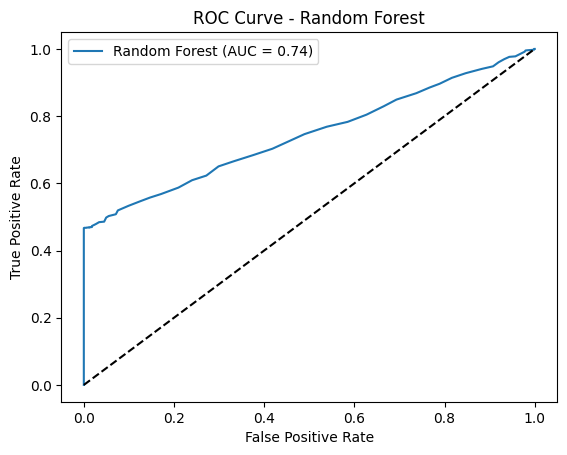

In [ ]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba_rf)
plt.plot(fpr, tpr, label="Random Forest (AUC = {:.2f})".format(roc_auc_score(y_test, y_proba_rf)))
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()